# Run MELD and compute perturbation scores

In [1]:
suppressPackageStartupMessages({
  library(Seurat)
  library(future)
  library(tidyverse)
})

In [ ]:
options(future.globals.maxSize = 1000000 * 1024^2, hpc.ncpus = 16)
plan(multicore, workers = getOption("hpc.ncpus", 1))
Sys.setenv(PATH = paste("/project/fuggerlab/rfarooq/.conda/envs/ocrelizumab_paper/bin", Sys.getenv("PATH"), sep = ":"), VROOM_CONNECTION_SIZE = "262144") # need to add conda environment bin directory system PATH variable to find C++ compiler
reticulate::use_condaenv(condaenv = "ocrelizumab_paper")

# Helper functions

In [3]:
source("../scripts/plotting.R")
source("../scripts/python.R")
Rcpp::sourceCpp("../scripts/tsv_row_stats.cpp")

Loading required package: reticulate



# Discovery cohort

### Load data

QS object generated by running notebooks in `03_annotate`

In [ ]:
seu <- qs::qread(file = "../data/processed/cite_seq/cohort_treatment_naive/annotated/annotated.qs", nthreads = getOption("hpc.ncpus", 1))

### Save integrated embedding

In [ ]:
dir.create("../data/processed/cite_seq/cohort_treatment_naive/embeddings", recursive = TRUE)
Embeddings(seu, reduction = "integrated.rna") %>%
  as.data.frame() %>%
  vroom::vroom_write(
    file = "../data/processed/cite_seq/cohort_treatment_naive/embeddings/integrated_rna.tsv.gz",
    delim = "\t",
    col_names = FALSE,
    quote = "none",
    num_threads = getOption("hpc.ncpus", 1)
  )

### Save replicate and condition metadata

In [ ]:
dir.create("../results/tables/cite_seq/cohort_treatment_naive/meld_simulations", recursive = TRUE)
write.table(
  FetchData(seu, vars = c("donor", "condition")),
  file = "../results/tables/cite_seq/cohort_treatment_naive/meld_simulations/metadata.tsv",
  sep = "\t",
  quote = FALSE,
  row.names = TRUE,
  col.names = TRUE
)

### Optimal MELD hyperparameters

MELD hyperparameter grid search results TSV generated by running `slurm/test_meld_hp_cohort_treatment_naive.sh`

In [ ]:
meld.hp.res <- read.table(
  file = "../results/tables/cite_seq/cohort_treatment_naive/test_meld_hp.tsv",
  sep = "\t",
  header = TRUE
) %>%
  group_by(k, beta) %>%
  summarise(mse = mean(mse)) %>%
  ungroup()

`summarise()` has grouped output by 'k'. You can override using the `.groups`
argument.


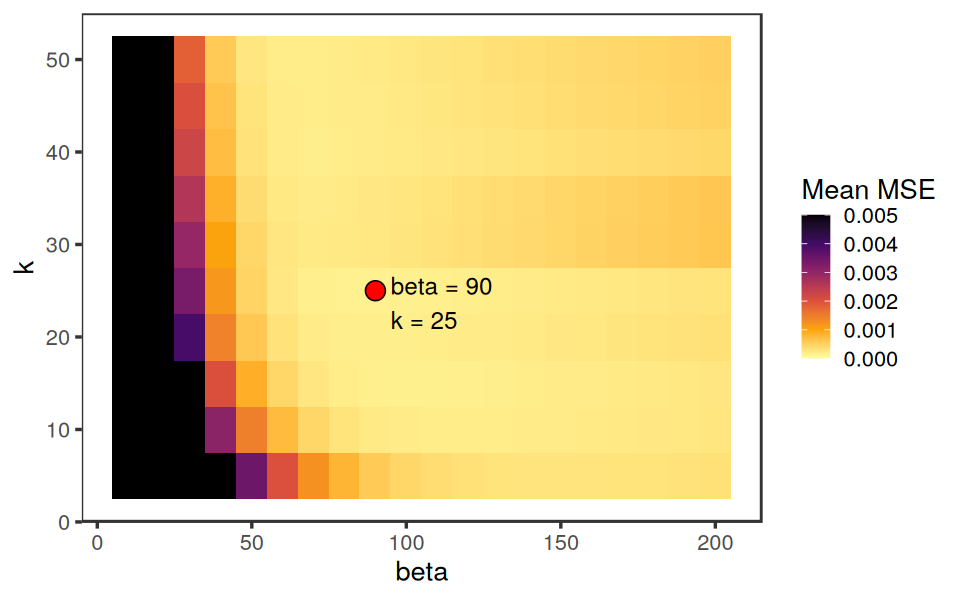

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 5)

chosen <- meld.hp.res %>%
  filter(mse == min(mse)) %>%
  unlist()

plot <- ggplot(data = meld.hp.res, mapping = aes(x = beta, y = k, fill = mse)) +
  geom_tile() +
  annotate(geom = "point", x = chosen["beta"], y = chosen["k"], shape = 21, size = 5, fill = "red") +
  annotate(geom = "text", x = chosen["beta"] + 5, y = chosen["k"] + 1.5, label = glue::glue("beta = {chosen['beta']}\nk = {chosen['k']}"), hjust = 0, vjust = 1, size = 5) +
  scale_fill_viridis_c(option = "inferno", direction = -1, limits = c(0, 0.005), na.value = "black") +
  labs(fill = "Mean MSE") +
  theme_custom()

plot

ggsave(
  filename = "../results/plots/cohort_treatment_naive_meld_hyperparameters.pdf",
  plot = plot,
  width = 8,
  height = 5,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

### MELD statistics

Empirical null distribution TSVs generated by running `slurm/meld_simulations_cohort_treatment_naive.sh`

In [ ]:
meld.null <- set_names(c("Early", "Late")) %>% 
  map(
    .f = function(x) {
      message("Computing empirical MELD null distribution statistics for condition '", x, "'")
      tsv_row_stats(file_path = glue::glue("../results/tables/cite_seq/cohort_treatment_naive/meld_simulations/{x}.tsv.gz"), max_rows = ncol(seu))
    }
  )

Computing empirical MELD null distribution statistics for condition 'Early'



[========================================] 100% (264512/264512)


Computing empirical MELD null distribution statistics for condition 'Late'



[========================================] 100% (264512/264512)


### Compute MELD likelihoods

In [ ]:
meld.likelihoods <- run.meld(
  data = Embeddings(seu, reduction = "integrated.rna"),
  cond = seu$condition,
  rep = seu$donor,
  k = chosen["k"],
  beta = chosen["beta"],
  simplify = FALSE
)

Loading Python libraries

Computing kNN graph with k = 25

Running MELD with beta = 90

Normalizing sample densities



### Split likelihoods by replicate

In [ ]:
rep <- unique(as.character(seu$donor))
meld.likelihoods <- lapply(
  rep,
  function(x, data) {
    data <- data[, grep(pattern = glue::glue("^{x}_"), x = colnames(data))]
    colnames(data) <- gsub(pattern = glue::glue("^{x}_"), replacement = "", x = colnames(data))
    return(data)
  },
  data = as.matrix(meld.likelihoods)
) %>%
  setNames(rep)

### Convert likelihoods to log likelihood ratios (relative to pre-treatment baseline)

In [ ]:
base.cond <- "Baseline"
log.lr <- lapply(
  meld.likelihoods,
  function(data) {
    lr <- apply(data, MARGIN = 2, function(x) x / data[, base.cond, drop = TRUE])
    lr <- lr[, colnames(lr) != base.cond, drop = FALSE]
    return(log(lr))
  }
)
conditions <- lapply(log.lr, colnames) %>%
  Reduce(f = c, x = .) %>%
  unique()
log.lr <- lapply(
  conditions,
  function(cond, data) {
    lapply(
      data,
      function(x) x[, cond, drop = TRUE]
    ) %>%
      data.frame() %>%
      as.matrix()
  },
  data = log.lr
) %>%
  setNames(conditions)

### Compute standardised perturbation scores and p-values

Confirm normality of null distributions to justify Z-test

In [ ]:
null <- set_names(c("Early", "Late")) %>%
  map(
    .f = function(x) {
      vroom::vroom(glue::glue("../results/tables/cite_seq/cohort_treatment_naive/meld_simulations/{x}.tsv.gz"), delim = "\t", col_names = FALSE, col_types = "d", num_threads = getOption("hpc.ncpus", 1)) %>%
        as.matrix()
    }
  ) %>%
  reduce(.f = rbind)

In [ ]:
centered <- null - rowMeans(null)
row.vars <- rowMeans(centered^2)
row.sd <- sqrt(row.vars)
moment.3 <- rowMeans(centered^3)
moment.4 <- rowMeans(centered^4)

skewness <- moment.3 / (row.sd^3)
kurtosis <- moment.4 / (row.sd^4)

data <- data.frame(
  Skewness = skewness,
  Kurtosis = kurtosis
)

Warning message:
"Removed 67 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 158 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."


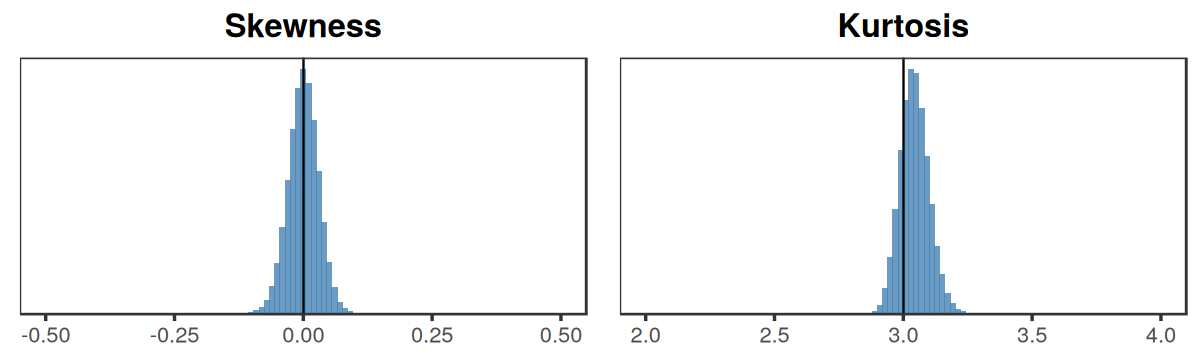

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 3)

plots <- map(
  .x = colnames(data),
  .f = function(x) {
    p <- ggplot(data = data, mapping = aes(x = get(x))) +
      geom_histogram(fill = "steelblue", colour = NA, alpha = 0.8, bins = 100) +
      geom_vline(xintercept = if (x == "Kurtosis") 3 else 0, color = "black") +
      scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
      labs(x = NULL, y = NULL, title = x) +
      theme_custom(
        plot.title = element_text(hjust = 0.5, face = "bold"),
        axis.title.y = element_text(face = "bold"),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank()
      )
    
    if (x == "Skewness") {
      p <- p + xlim(c(-0.5, 0.5))
    } else {
      p <- p + xlim(c(2, 4))
    }

    return(p)
  }
)

final.plot <- cowplot::plot_grid(plotlist = plots, nrow = 1)

final.plot

ggsave(
  filename = "../results/plots/meld_null_skewness_kurtosis.pdf",
  plot = final.plot,
  width = 10,
  height = 3,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

Compute permutation-based Z-statistics, p-values and weighted BH adjusted p-values 

In [ ]:
# Pre-compute kNN distances for weighting p-values
knn <- BiocNeighbors::findKNN(
  Embeddings(seu, reduction = "integrated.rna"),
  k = chosen["k"],
  BNPARAM = BiocNeighbors::AnnoyParam()
)
dist.k <- knn$distance[, chosen["k"]]
weights <- dist.k / mean(dist.k) # normalize weights to have mean 1 (required for weighted BH to control FDR)

In [ ]:
meld.stats <- map2(
  .x = log.lr,
  .y = meld.null,
  .f = function(x, y) {
    stats <- y %>%
      mutate(obs = MatrixGenerics::rowMedians(x, na.rm = TRUE)) %>%
      transmute(
        z = (obs - mean) / sd,
        p = 2 * pnorm(-abs(z)),
        q = p / weights,
        q_adj = p.adjust(q, method = "BH")
      )
    rownames(stats) <- rownames(x)
    return(stats)
  }
)

Save results

In [ ]:
walk2(
  .x = meld.stats,
  .y = names(meld.stats),
  .f = function(x, name) {
    write.table(
      x, 
      file = glue::glue("../results/tables/cite_seq/cohort_treatment_naive/meld_stats_{name}.tsv"),
      sep = "\t",
      quote = FALSE,
      col.names = TRUE,
      row.names = TRUE
    )
  }
)

# Natalizumab PBMC validation cohort

### Load data

QS object generated by running notebooks in `03_annotate`

In [ ]:
seu <- qs::qread(file = "../data/processed/external/kaufmann/annotated/kaufmann_natalizumab_filtered.qs", nthreads = getOption("hpc.ncpus", 1))

### Save integrated embedding

In [ ]:
dir.create("../data/processed/external/kaufmann/embeddings", recursive = TRUE)
Embeddings(seu, reduction = "integrated.rna") %>%
  as.data.frame() %>%
  vroom::vroom_write(
    file = "../data/processed/external/kaufmann/embeddings/integrated_rna.tsv.gz",
    delim = "\t",
    col_names = FALSE,
    quote = "none",
    num_threads = getOption("hpc.ncpus", 1)
  )

### Save replicate and condition metadata

In [ ]:
dir.create("../results/tables/external/kaufmann/meld_simulations", recursive = TRUE)
write.table(
  FetchData(seu, vars = c("donor", "condition")),
  file = "../results/tables/external/kaufmann/meld_simulations/metadata.tsv",
  sep = "\t",
  quote = FALSE,
  row.names = TRUE,
  col.names = TRUE
)

### Optimal MELD hyperparameters

MELD hyperparameter grid search results TSV generated by running `slurm/test_meld_hp_kaufmann.sh`

In [ ]:
meld.hp.res <- read.table(
  file = "../results/tables/external/kaufmann/test_meld_hp.tsv",
  sep = "\t",
  header = TRUE
) %>%
  group_by(k, beta) %>%
  summarise(mse = mean(mse)) %>%
  ungroup()

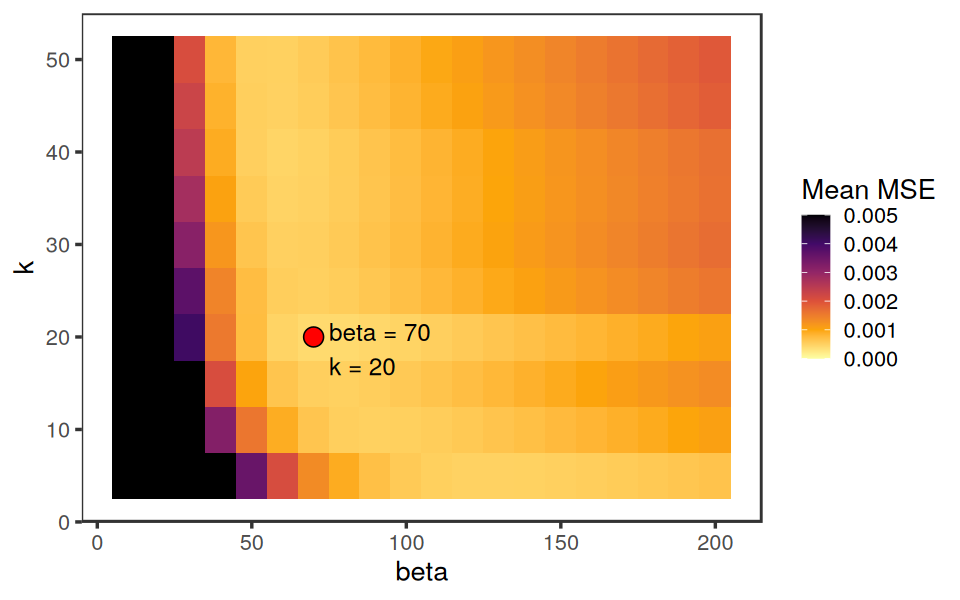

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 5)

chosen <- meld.hp.res %>%
  filter(mse == min(mse)) %>%
  unlist()

plot <- ggplot(data = meld.hp.res, mapping = aes(x = beta, y = k, fill = mse)) +
  geom_tile() +
  annotate(geom = "point", x = chosen["beta"], y = chosen["k"], shape = 21, size = 5, fill = "red") +
  annotate(geom = "text", x = chosen["beta"] + 5, y = chosen["k"] + 1.5, label = glue::glue("beta = {chosen['beta']}\nk = {chosen['k']}"), hjust = 0, vjust = 1, size = 5) +
  scale_fill_viridis_c(option = "inferno", direction = -1, limits = c(0, 0.005), na.value = "black") +
  labs(fill = "Mean MSE") +
  theme_custom()

plot

ggsave(
  filename = "../results/plots/kaufmann_natalizumab_meld_hyperparameters.pdf",
  plot = plot,
  width = 8,
  height = 5,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

### MELD statistics

Empirical null distribution TSVs generated by running `slurm/meld_simulations_kaufmann.sh`

In [ ]:
meld.null <- set_names("Post") %>% 
  map(
    .f = function(x) {
      message("Computing empirical MELD null distribution statistics for condition '", x, "'")
      tsv_row_stats(file_path = glue::glue("../results/tables/external/kaufmann/meld_simulations/{x}.tsv.gz"), max_rows = ncol(seu))
    }
  )

Computing empirical MELD null distribution statistics for condition 'Post'



[========================================] 100% (56252/56252)


### Compute MELD likelihoods

In [ ]:
meld.likelihoods <- run.meld(
  data = Embeddings(seu, reduction = "integrated.rna"),
  cond = seu$condition,
  rep = seu$donor,
  k = chosen["k"],
  beta = chosen["beta"],
  simplify = FALSE
)

Loading Python libraries

Computing kNN graph with k = 20

Running MELD with beta = 70

Normalizing sample densities



### Split likelihoods by replicate

In [ ]:
rep <- unique(as.character(seu$donor))
meld.likelihoods <- lapply(
  rep,
  function(x, data) {
    colnames(data) <- gsub(pattern = "\\.", replacement = "-", x = colnames(data))
    data <- data[, grep(pattern = glue::glue("^{x}_"), x = colnames(data))]
    colnames(data) <- gsub(pattern = glue::glue("^{x}_"), replacement = "", x = colnames(data))
    return(data)
  },
  data = as.matrix(meld.likelihoods)
) %>%
  setNames(rep)

### Convert likelihoods to log likelihood ratios (relative to pre-treatment baseline)

In [ ]:
base.cond <- "Pre"
log.lr <- lapply(
  meld.likelihoods,
  function(data) {
    lr <- apply(data, MARGIN = 2, function(x) x / data[, base.cond, drop = TRUE])
    lr <- lr[, colnames(lr) != base.cond, drop = FALSE]
    return(log(lr))
  }
)
conditions <- lapply(log.lr, colnames) %>%
  Reduce(f = c, x = .) %>%
  unique()
log.lr <- lapply(
  conditions,
  function(cond, data) {
    lapply(
      data,
      function(x) x[, cond, drop = TRUE]
    ) %>%
      data.frame() %>%
      as.matrix()
  },
  data = log.lr
) %>%
  setNames(conditions)

### Compute standardised perturbation scores and p-values

Compute permutation-based Z-statistics, p-values and weighted BH adjusted p-values 

In [ ]:
# Pre-compute kNN distances for weighting p-values
knn <- BiocNeighbors::findKNN(
  Embeddings(seu, reduction = "integrated.rna"),
  k = chosen["k"],
  BNPARAM = BiocNeighbors::AnnoyParam()
)
dist.k <- knn$distance[, chosen["k"]]
weights <- dist.k / mean(dist.k) # normalize weights to have mean 1 (required for weighted BH to control FDR)

In [ ]:
meld.stats <- map2(
  .x = log.lr,
  .y = meld.null,
  .f = function(x, y) {
    stats <- y %>%
      mutate(obs = MatrixGenerics::rowMedians(x, na.rm = TRUE)) %>%
      transmute(
        z = (obs - mean) / sd,
        p = 2 * pnorm(-abs(z)),
        q = p / weights,
        q_adj = p.adjust(q, method = "BH")
      )
    rownames(stats) <- rownames(x)
    return(stats)
  }
)

Save results

In [ ]:
walk2(
  .x = meld.stats,
  .y = names(meld.stats),
  .f = function(x, name) {
    write.table(
      x, 
      file = glue::glue("../results/tables/external/kaufmann/meld_stats_{name}.tsv"),
      sep = "\t",
      quote = FALSE,
      col.names = TRUE,
      row.names = TRUE
    )
  }
)

In [4]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /ceph/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
[1] C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] reticulate_1.39.0  lubridate_1.9.3    forcats_1.0.0      stringr_1.5.1     
 [5] dplyr_1.1.4        purrr_1.0.2        readr_2.1.5        tidyr_1.3.1       
 [9] tibble_3.2.1       ggplot2_3.5.1      tidyverse_2.0.0    future_1.34.0     
[13] Seurat_5.1.0       SeuratObject_5.0.2 sp_2.1-4          

loaded via a namespace (and not attached):
  [1] deldir_2.0-4           pbapply_1.7-2          gridExtra_2.3         
  [4] rlang_1.1.4            magrittr_2.0.3         RcppAnnoy_0.0.22      
  [7] spatstat.geom_3.2-9    matrixStats_1.4.1      ggrid